<a href="https://colab.research.google.com/github/deshmukhvaishnavi04/celebal-internship/blob/main/week2_vaishnavi_deshmukh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()


Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025.csv


##Loading the Dataset


In [3]:
df=pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
print("\nInfo:")
df.info()

print("\nDescribe:")
display(df.describe())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB

Describe:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


##Missing Values and Duplicates

In [5]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Missing Values
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows
0


##**EDA chart Analysis**



###Deliveries by Model

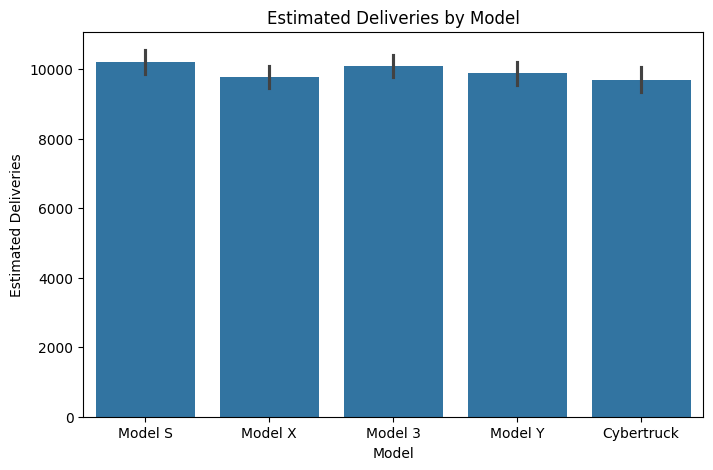

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Model',
    y='Estimated_Deliveries'
)
plt.title("Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.show()

###Deliveries by Region

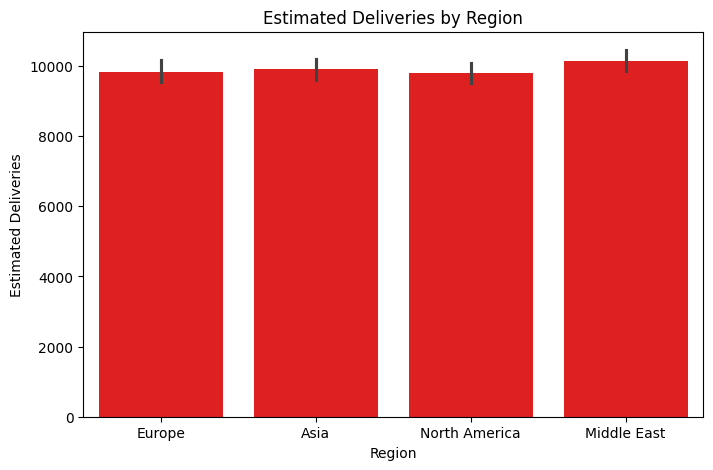

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Region',
    y='Estimated_Deliveries',
    color = 'red'
)

plt.title("Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")

plt.show()

###Correlation Heatmap

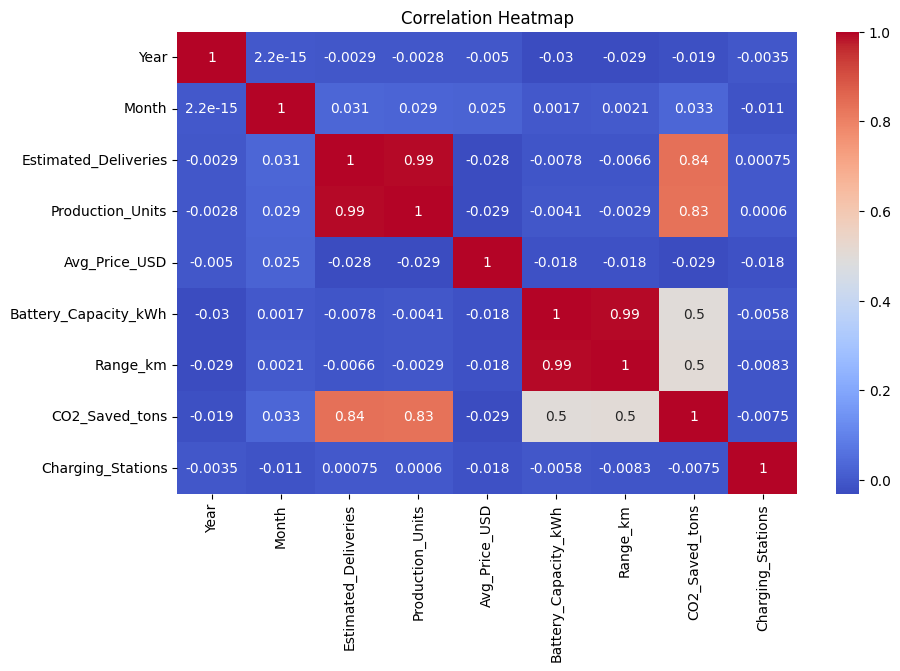

In [8]:
num_cols = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))

sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

###Production vs Deliveries Scatter Plot

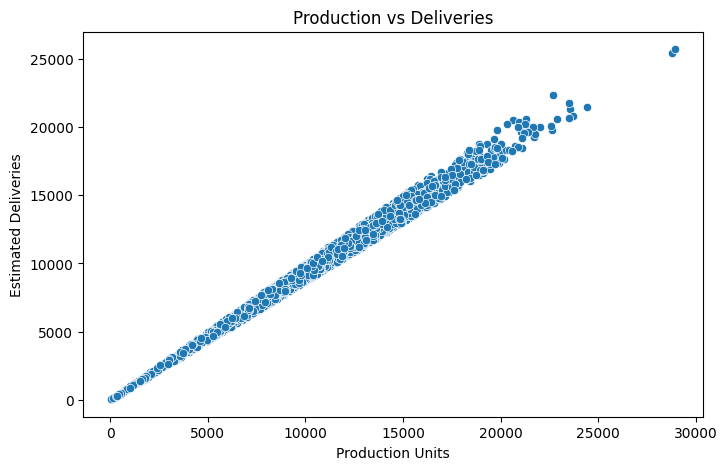

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Production_Units',
    y='Estimated_Deliveries'
)

plt.title("Production vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

###Time Trend Line

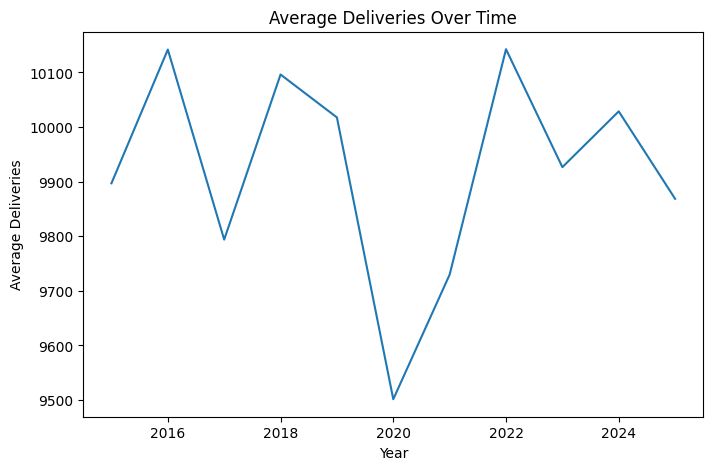

In [10]:
trend = df.groupby('Year')['Estimated_Deliveries'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=trend,
    x='Year',
    y='Estimated_Deliveries'
)

plt.title("Average Deliveries Over Time")
plt.xlabel("Year")
plt.ylabel("Average Deliveries")

plt.show()

##Label Encoding


#####The categorical columns such as Model, Region, and Source_Type were converted into numeric form using Label Encoding. This was done because machine learning models work better with numerical data than text values.



##### A new feature called Deliveries_Lag1 was created using the previous delivery value.It helps the model understand how past deliveries may influence future deliveries.



#####Another feature, Rolling_Mean_3, was created by taking the average of the last three observations. This helps reduce random fluctuations in the data and makes overall trends easier to identify. Any missing values generated during this process were filled using the mean of the respective feature.


In [11]:
from sklearn.preprocessing import LabelEncoder

le_model = LabelEncoder()
le_region = LabelEncoder()
le_source = LabelEncoder()

df['Model'] = le_model.fit_transform(df['Model'])
df['Region'] = le_region.fit_transform(df['Region'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

###Lag Mean

In [33]:
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)

df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna(
    df['Deliveries_Lag1'].mean()
)


###Rolling Mean

In [13]:
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(3)
    .mean()
)

df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(
    df['Rolling_Mean_3'].mean()
)
df[['Estimated_Deliveries', 'Deliveries_Lag1']].head()

,Estimated_Deliveries,Deliveries_Lag1
0,17646,9924.959454
1,3797,17646.000000
2,8411,3797.000000
3,6555,8411.000000
4,12374,6555.000000


###80/20 Split and Linear Regression

In [14]:
print(df[['Estimated_Deliveries',
          'Deliveries_Lag1',
          'Rolling_Mean_3']].head())

   Estimated_Deliveries  Deliveries_Lag1  Rolling_Mean_3
0                 17646      9924.959454     9923.677407
1                  3797     17646.000000     9923.677407
2                  8411      3797.000000     9951.333333
3                  6555      8411.000000     6254.333333
4                 12374      6555.000000     9113.333333


In [15]:
y = df['Estimated_Deliveries']
X = df.drop('Estimated_Deliveries', axis=1)

In [16]:
split_idx = int(0.8 * len(df))

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [17]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred_lr)

rmse = np.sqrt(
    mean_squared_error(y_test,pred_lr)
)

r2 = r2_score(y_test,pred_lr)

print(mae)
print(rmse)
print(r2)

310.3345215398842
375.5646664534478
0.9908058721380986



######The dataset was divided chronologically using index slicing, where the first 80% of observations were used for training and the remaining 20% were used for testing. This approach preserves the temporal order of the data and avoids data leakage.





######A Linear Regression model was trained to predict Estimated_Deliveries. The model achieved an R² score of approximately 0.991, indicating that more than 99% of the variation in deliveries is explained by the selected features. The low MAE and RMSE values further demonstrate strong predictive performance

###Actual vs Predicted

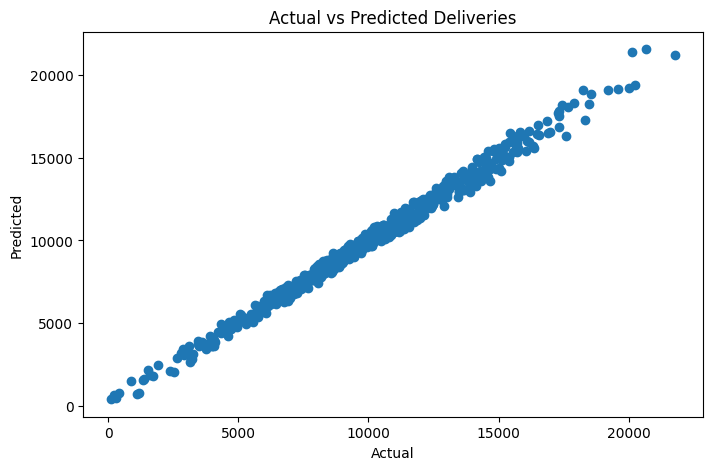

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(y_test,pred_lr)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Deliveries")

plt.show()

###5-Fold Cross Validation

In [20]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(cv_scores)

print("Mean:",cv_scores.mean())
print("Std:",cv_scores.std())

[0.99064898 0.99046596 0.98949291 0.99051101 0.99080587]
Mean: 0.9903849476659861
Std: 0.00046153530925534015


######Five-fold cross validation was performed to evaluate model stability and generalization performance. The dataset was divided into five subsets, with each subset serving as a validation set once. The mean R² score and standard deviation were calculated to assess consistency across folds. The results indicate that the model performs reliably on different data partitions.



###Random Forest and GridSearchCV

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[50,100],
    'max_depth':[5,10,None]
}

rf = RandomForestRegressor(
    random_state=42
)

grid = GridSearchCV(
    rf,
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, None], 'n_estimators': [50, 100]},
             scoring='r2')

In [22]:
print(grid.best_params_)


{'max_depth': None, 'n_estimators': 50}


Prediction:

In [23]:
best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test)

print(
    r2_score(y_test,rf_pred)
)

0.99015903323468


###Top 10 Feature Importances

In [24]:
imp = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_rf.feature_importances_
})

imp = imp.sort_values(
    by='Importance',
    ascending=False
)

top10 = imp.head(10)

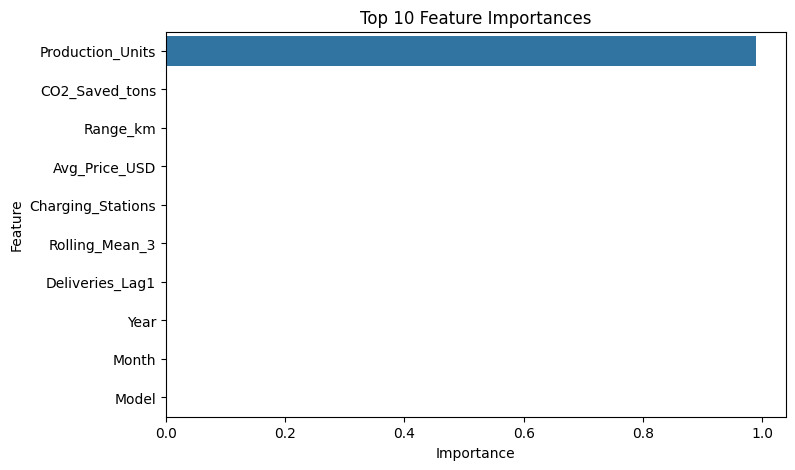

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances")
plt.show()

In [26]:
print(df['Production_Units'].corr(df['Estimated_Deliveries']))

0.9942343488939529


In [27]:
top10


,Feature,Importance
4,Production_Units,0.990055
8,CO2_Saved_tons,0.002163
7,Range_km,0.001221
5,Avg_Price_USD,0.001040
10,Charging_Stations,0.001004
12,Rolling_Mean_3,0.000955
11,Deliveries_Lag1,0.000923
0,Year,0.000888
1,Month,0.000668
3,Model,0.000357


######Feature importance analysis revealed that Production_Units is the most influential predictor of Estimated_Deliveries. This finding aligns with domain expectations because vehicle deliveries are strongly dependent on production volume. Other features contributed comparatively less to the prediction process.

###ADF Test

In [28]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(
    df['Estimated_Deliveries']
)

print("ADF Statistic:",result[0])
print("p-value:",result[1])

ADF Statistic: -53.82661259715622
p-value: 0.0


The Augmented Dickey-Fuller (ADF) test was performed on the Estimated_Deliveries series to check stationarity. The obtained p-value was 0.0, which is less than the significance level of 0.05. Therefore, the null hypothesis of non-stationarity is rejected. This indicates that the Estimated_Deliveries series is stationary and does not exhibit a unit root

In [29]:
if result[1] < 0.05:
    print("Stationary")
else:
    print("Non-stationary")

Stationary


###Time Series Forecasting using ARIMA

 Time Series Forecasting:
 An ARIMA(1,1,1) model is used to forecast future Tesla deliveries based on
 historical delivery data. The forecast helps identify upcoming trends and
 supports business planning and decision-making

In [30]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Use delivery data as a time series
series = df['Estimated_Deliveries']

# Train ARIMA model
arima_model = ARIMA(series, order=(1,1,1))
arima_result = arima_model.fit()

# Forecast next 5 periods
future_forecast = arima_result.forecast(steps=5)

print("Future Delivery Forecast:")
print(future_forecast)

Future Delivery Forecast:
2640    10259.138103
2641     9903.046339
2642     9919.686634
2643     9918.909027
2644     9918.945364
Name: predicted_mean, dtype: float64


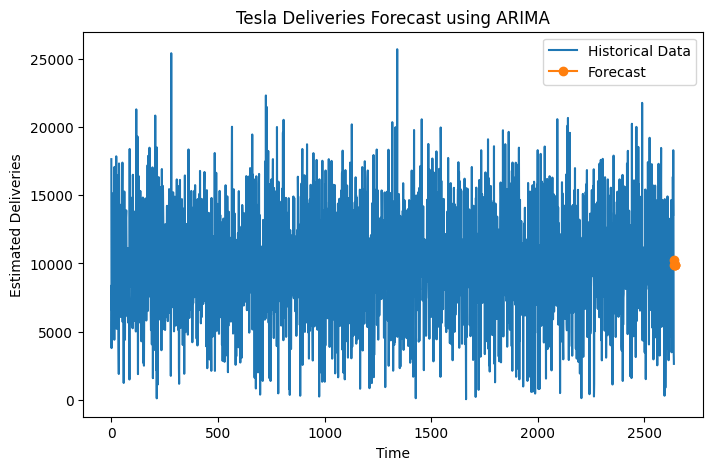

In [31]:
plt.figure(figsize=(8,5))

plt.plot(series.values, label='Historical Data')

plt.plot(
    range(len(series), len(series) + 5),
    future_forecast,
    marker='o',
    label='Forecast'
)

plt.title("Tesla Deliveries Forecast using ARIMA")
plt.xlabel("Time")
plt.ylabel("Estimated Deliveries")
plt.legend()

plt.show()

######The ARIMA model predicts future delivery values using historical trends.

###Forecast Comparison Table

In [34]:
forecast = pd.DataFrame({
    'Actual':y_test.values,
    'Predicted':rf_pred
})

forecast['Error_%'] = (
    abs(
        forecast['Actual']
        -
        forecast['Predicted']
    )
    /
    forecast['Actual']
) * 100

forecast.head(20)

,Actual,Predicted,Error_%
0,11974,11244.76,6.090195
1,9189,8947.18,2.631625
2,15956,16791.60,5.236901
3,10336,10896.56,5.423375
4,15152,15868.72,4.730201
5,4224,4014.38,4.962595
6,8475,8863.10,4.579351
7,4093,3817.50,6.731004
8,2972,3149.94,5.987214
9,8208,8202.68,0.064815


The forecast comparison table presents the first 20 records from the test dataset. The predicted delivery values are generally close to the actual values, with most percentage errors remaining below 6%. This indicates that the trained Random Forest model is able to capture the relationship between production, pricing, battery capacity, and other features effectively, resulting in accurate delivery forecast

# conclusion

This project analyzed Tesla delivery and production data from 2015–2025 using exploratory data analysis, feature engineering, and predictive modeling techniques. Strong relationships were observed between production units and estimated deliveries. Both Linear Regression and Random Forest models achieved excellent predictive performance, with R² values exceeding 0.99. The ADF test confirmed stationarity of the delivery series, and feature importance analysis identified Production_Units as the dominant predictor. Overall, the analysis demonstrates the effectiveness of machine learning methods for forecasting Tesla delivery trends.